# 📰 Intelligent Multi-Class Text Classifier

## Objective
Build a multi-class NLP classifier that categorizes news articles into **5 categories** (business, entertainment, politics, sport, tech) using **TF-IDF** feature extraction and classical machine learning models, evaluated primarily on **F1-Score**.

## Tech Stack
- **Preprocessing:** NLTK (stopword removal, WordNet Lemmatization)
- **Feature Extraction:** TF-IDF Vectorizer (scikit-learn)
- **Models:** Multinomial Naive Bayes, Logistic Regression, LinearSVC
- **Evaluation:** F1-Score (macro and weighted), Confusion Matrix

## Dataset
BBC News Classification — **2,225 news articles** labeled across 5 categories.  
File: `data/bbc_text_cls.csv` with columns `text` (article body) and `labels` (category).

In [1]:
# ──────────────────────────────────────────────
# Standard Libraries
# ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os
import pickle

# ──────────────────────────────────────────────
# NLTK — Natural Language Toolkit
# ──────────────────────────────────────────────
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ──────────────────────────────────────────────
# Scikit-learn
# ──────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

# ──────────────────────────────────────────────
# Global Settings
# ──────────────────────────────────────────────
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("\u2705 All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 1: Data Loading & Initial Inspection
We load the dataset, verify its structure, and check data health (nulls, duplicates) before any processing.

In [2]:
# Load the dataset
df = pd.read_csv('data/bbc_text_cls.csv')

# Rename 'labels' → 'category' for clarity
df = df.rename(columns={'labels': 'category'})

# ──────────────────────────────────────────────
# Initial Inspection
# ──────────────────────────────────────────────
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(df.shape)

print("\n" + "=" * 50)
print("COLUMN NAMES")
print("=" * 50)
print(list(df.columns))

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
df.head(5)

# (head() displayed above via notebook rendering; also print dtypes, nulls, duplicates)
print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("NULL VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# ──────────────────────────────────────────────
# Handle Duplicates
# Duplicate articles can appear in both train and test
# sets, causing data leakage and inflating accuracy.
# ──────────────────────────────────────────────
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("\n" + "=" * 50)
print("DUPLICATE REMOVAL")
print("=" * 50)
print(f"Duplicates removed: {rows_before - len(df)}")
print(f"Final dataset shape: {df.shape}")

# Unique categories
print("\n" + "=" * 50)
print("CATEGORIES")
print("=" * 50)
print(f"Categories ({df['category'].nunique()}): {sorted(df['category'].unique())}")

DATASET SHAPE
(2225, 2)

COLUMN NAMES
['text', 'category']

FIRST 5 ROWS

DATA TYPES
text        str
category    str
dtype: object

NULL VALUES PER COLUMN
text        0
category    0
dtype: int64

DUPLICATE ROWS
Number of duplicate rows: 98

DUPLICATE REMOVAL
Duplicates removed: 98
Final dataset shape: (2127, 2)

CATEGORIES
Categories (5): ['business', 'entertainment', 'politics', 'sport', 'tech']


In [3]:
# ──────────────────────────────────────────────
# Text Length Statistics
# ──────────────────────────────────────────────
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("=" * 50)
print("TEXT LENGTH STATISTICS")
print("=" * 50)
print(df[['char_count', 'word_count']].describe().round(1))

# ──────────────────────────────────────────────
# Sample Articles (first 300 chars per category)
# ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("SAMPLE ARTICLES (first 300 chars)")
print("=" * 50)
for category in sorted(df['category'].unique()):
    sample_text = df[df['category'] == category]['text'].iloc[0]
    print(f"\n▶ [{category.upper()}]")
    print(f"{sample_text[:300]}...")
    print("-" * 50)

print("\n\u2705 Data loading complete!")

TEXT LENGTH STATISTICS
       char_count  word_count
count      2127.0      2127.0
mean       2264.0       384.1
std        1381.7       241.4
min         502.0        89.0
25%        1439.5       245.0
50%        1958.0       331.0
75%        2802.0       471.0
max       25484.0      4432.0

SAMPLE ARTICLES (first 300 chars)

▶ [BUSINESS]
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and highe...
--------------------------------------------------

▶ [ENTERTAINMENT]
Gallery unveils interactive tree

A Christmas tree that can receive text messages has been unveiled at London's Tate Britain art gallery.

The spruce has an antenna which can receive Bluetooth texts sent by visitors to the Tate. The messages will be "unwrapped" by sculptor Richard We

## 📊 Step 2: Class Distribution Analysis
Before modelling, we check whether the 5 categories are balanced. Class imbalance matters here because our primary metric is **F1-Score**. Macro-F1 treats every class equally, so a rare class that the model learns poorly will pull the score down.

In [4]:
# ──────────────────────────────────────────────
# Class Distribution Table & Imbalance Metrics
# ──────────────────────────────────────────────
class_counts = df['category'].value_counts()
class_pct = df['category'].value_counts(normalize=True) * 100

# Build summary DataFrame
class_summary = pd.DataFrame({
    'Category': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_pct.values.round(2)
})

print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)
print(class_summary.to_string(index=False))

# Imbalance insights
largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()
imbalance_ratio = round(class_counts.max() / class_counts.min(), 2)

print("\n" + "=" * 50)
print("IMBALANCE INSIGHTS")
print("=" * 50)
print(f"Largest class:  {largest_class} ({class_counts.max()} articles)")
print(f"Smallest class: {smallest_class} ({class_counts.min()} articles)")
print(f"Imbalance ratio (max/min): {imbalance_ratio}")

if imbalance_ratio < 1.5:
    verdict = "\u2705 Dataset is well balanced"
elif imbalance_ratio < 3:
    verdict = "\u26a0\ufe0f Mild imbalance — acceptable"
else:
    verdict = "\u274c Significant imbalance — consider class weights"

print(f"Verdict: {verdict}")

CLASS DISTRIBUTION
     Category  Count  Percentage
        sport    505       23.74
     business    503       23.65
     politics    403       18.95
entertainment    369       17.35
         tech    347       16.31

IMBALANCE INSIGHTS
Largest class:  sport (505 articles)
Smallest class: tech (347 articles)
Imbalance ratio (max/min): 1.46
Verdict: ✅ Dataset is well balanced


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/1664316927.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


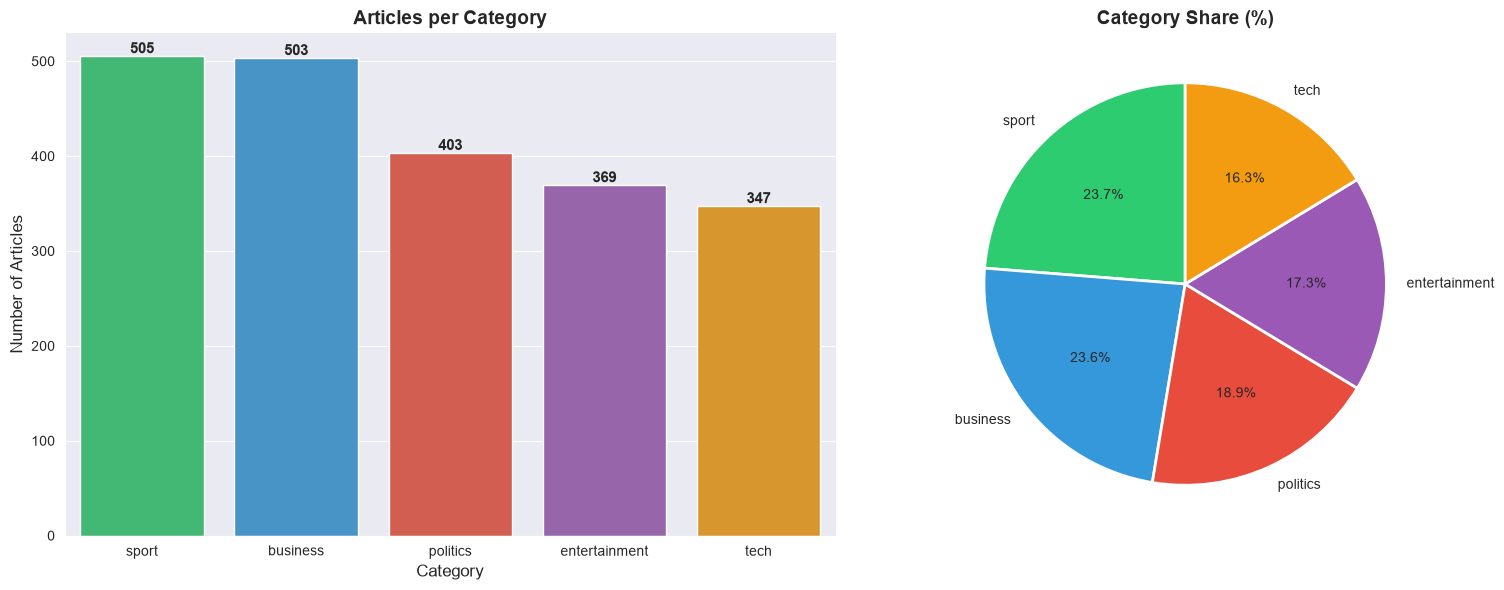

In [5]:
# ──────────────────────────────────────────────
# Consistent Color Palette (used across entire notebook)
# ──────────────────────────────────────────────
palette = {
    'business': '#3498db',
    'entertainment': '#9b59b6',
    'politics': '#e74c3c',
    'sport': '#2ecc71',
    'tech': '#f39c12'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Bar Chart ───
ax1 = axes[0]
sns.countplot(
    x='category', data=df,
    order=class_counts.index,
    palette=palette,
    ax=ax1
)
# Add count labels on top of each bar
for bar in ax1.patches:
    ax1.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax1.set_title('Articles per Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Number of Articles', fontsize=12)

# ─── Plot 2: Pie Chart ───
ax2 = axes[1]
pie_colors = [palette[cat] for cat in class_counts.index]
ax2.pie(
    class_counts.values,
    labels=class_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title('Category Share (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

WORD COUNT STATISTICS BY CATEGORY
                mean  median  min   max
category                               
tech           513.2   460.0  162  2969
politics       456.2   439.0   89  4432
entertainment  332.7   262.0  143  3482
sport          330.6   291.0  114  1662
business       328.7   297.0  140   891


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/1740673299.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


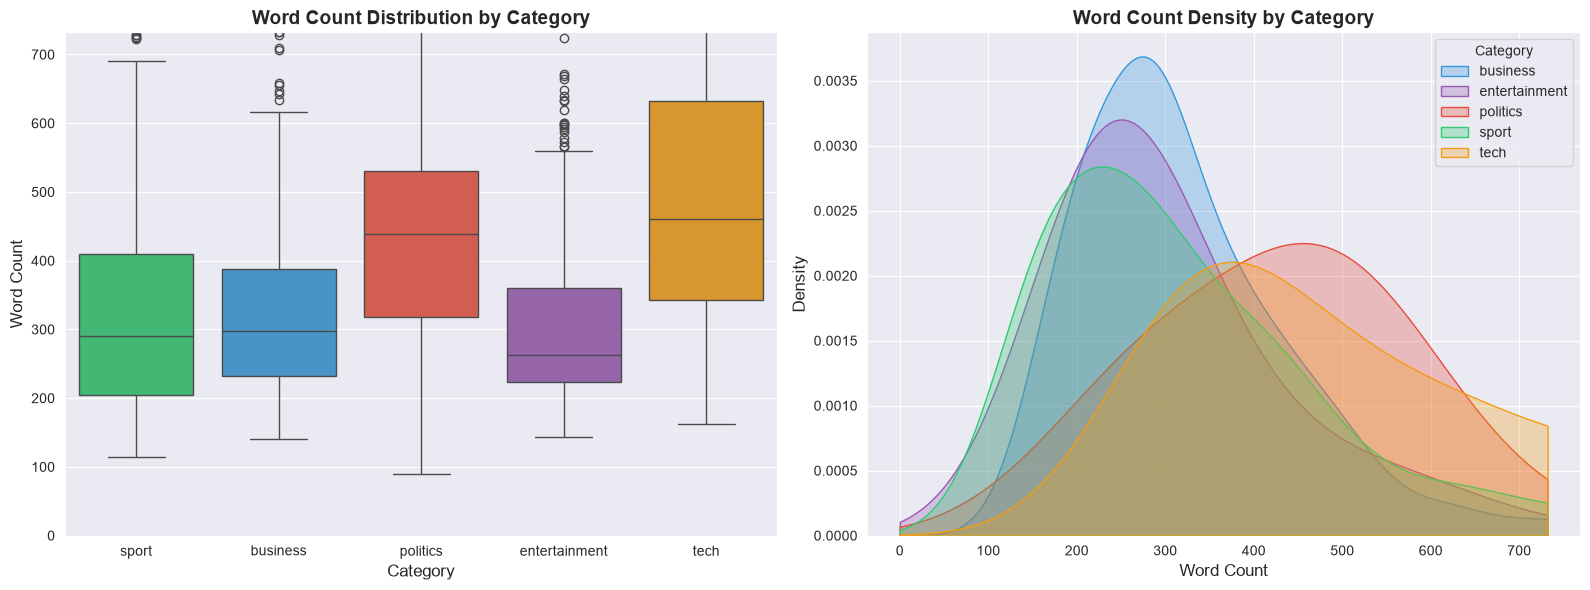

In [6]:
# ──────────────────────────────────────────────
# Article Length Analysis per Category
# ──────────────────────────────────────────────
print("=" * 50)
print("WORD COUNT STATISTICS BY CATEGORY")
print("=" * 50)
length_stats = (
    df.groupby('category')['word_count']
    .agg(['mean', 'median', 'min', 'max'])
    .round(1)
    .sort_values('mean', ascending=False)
)
print(length_stats)

# 95th percentile cap for cleaner visuals
word_count_p95 = df['word_count'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Box Plot ───
ax1 = axes[0]
sns.boxplot(
    x='category', y='word_count', data=df,
    palette=palette,
    order=class_counts.index,
    ax=ax1
)
ax1.set_ylim(0, word_count_p95)
ax1.set_title('Word Count Distribution by Category', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Word Count', fontsize=12)

# ─── Plot 2: Overlapping KDE ───
ax2 = axes[1]
for category in sorted(df['category'].unique()):
    subset = df[df['category'] == category]['word_count']
    sns.kdeplot(
        subset,
        clip=(0, word_count_p95),
        fill=True,
        alpha=0.3,
        color=palette[category],
        label=category,
        ax=ax2
    )
ax2.set_title('Word Count Density by Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Word Count', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(title='Category')

plt.tight_layout()
plt.savefig('outputs/02_word_count_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Observations

- **Most / fewest articles:** **Sport** has the most articles (**505 articles**, 23.74%), closely followed by **Business** (**503 articles**, 23.65%). **Tech** has the fewest articles (**347 articles**, 16.31%), with **Entertainment** (369, 17.35%) and **Politics** (403, 18.95%) in the middle.
- **Balance verdict:** The imbalance ratio is **1.46** (505 / 347). Because this is below **1.5**, the **dataset is well balanced**. There is no need for synthetic oversampling (e.g. SMOTE) or class reweighting, and **Macro-F1** will give an honest, unskewed assessment of multi-class performance.
- **Longest articles:** **Tech** and **Politics** articles are substantially longer and more detailed:
  - *Tech:* Highest average at **513.2 words** (median: 460.0 words).
  - *Politics:* Second highest at **456.2 words** (median: 439.0 words) and holds the longest single article in the dataset (4,432 words).
  - *Entertainment* (332.7 words), *Sport* (330.6 words), and *Business* (328.7 words) are much more compact, clustering around ~330 words on average.

✅ Class distribution analysis complete!

## 🧹 Step 3: Text Preprocessing Pipeline
Raw text must be cleaned before it can be converted to numbers. Our pipeline applies these steps in order:

| Step | Action | Example |
|------|--------|---------|
| 1 | **Lowercase** | "Profits" → "profits" |
| 2 | **Remove URLs & emails** | "visit http://bbc.co.uk" → "visit" |
| 3 | **Remove numbers & punctuation** | "$1.13bn!" → "bn" |
| 4 | **Tokenize** | "profits rose" → ["profits", "rose"] |
| 5 | **Remove stopwords** | ["the", "firm", "is"] → ["firm"] |
| 6 | **Lemmatize (POS-aware)** | "running" → "run", "companies" → "company" |

### Why Lemmatization over Stemming?
Stemming crudely chops word endings (e.g. "studies" → "studi"), while lemmatization uses a dictionary to return a real root word (e.g. "studies" → "study"). WordNetLemmatizer defaults to treating every word as a noun, so we first tag each word’s part of speech (noun / verb / adjective / adverb) and pass that to the lemmatizer for accurate results.

In [7]:
# ──────────────────────────────────────────────
# NLTK Resources & Tool Initialization
# ──────────────────────────────────────────────
# Download POS tagger (resource name differs across NLTK versions)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print(f"Number of English stopwords: {len(stop_words)}")
print(f"Sample stopwords (first 15): {sorted(stop_words)[:15]}")

Number of English stopwords: 198
Sample stopwords (first 15): ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [8]:
# ──────────────────────────────────────────────
# POS Tag Mapper: Penn Treebank → WordNet
# ──────────────────────────────────────────────
from nltk import pos_tag
from nltk.corpus import wordnet


def get_wordnet_pos(treebank_tag):
    """Map a Penn Treebank POS tag to the corresponding WordNet POS tag.

    This lets WordNetLemmatizer produce accurate lemmas by knowing
    whether a word is a noun, verb, adjective, or adverb.
    """
    if treebank_tag.startswith('J'):   # Adjective
        return wordnet.ADJ
    elif treebank_tag.startswith('V'): # Verb
        return wordnet.VERB
    elif treebank_tag.startswith('R'): # Adverb
        return wordnet.ADV
    else:                              # Default → Noun
        return wordnet.NOUN


print("\u2705 POS tag mapper defined.")

✅ POS tag mapper defined.


In [9]:
# ──────────────────────────────────────────────
# Main Preprocessing Function
# ──────────────────────────────────────────────

def preprocess_text(text):
    """
    Clean raw text and return a lemmatized string with stopwords
    removed. This exact function must be reused unchanged in the
    Streamlit app for consistent predictions.
    """
    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # 4. Remove everything that is not a letter or whitespace
    #    (handles numbers AND punctuation in one step)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenize
    tokens = word_tokenize(text)

    # 7. Remove stopwords and tokens shorter than 3 characters
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 3]

    # 8. POS-tag the remaining tokens
    tagged_tokens = pos_tag(tokens)

    # 9. Lemmatize each token with its POS tag
    lemmatized_tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

    # 10. Rejoin into a single string
    return ' '.join(lemmatized_tokens)


# ─── Quick Test ───
test = "The companies were running their profits up by 25% — visit https://bbc.co.uk!"
print("=" * 50)
print("PREPROCESSING TEST")
print("=" * 50)
print(f"Original : {test}")
print(f"Cleaned  : {preprocess_text(test)}")

PREPROCESSING TEST
Original : The companies were running their profits up by 25% — visit https://bbc.co.uk!
Cleaned  : company run profit visit


In [10]:
# ──────────────────────────────────────────────
# Apply Pipeline to Entire Dataset
# ──────────────────────────────────────────────
import time

print("⏳ Preprocessing all articles (this may take 1-2 minutes)...")
start_time = time.time()

df['text_clean'] = df['text'].apply(preprocess_text)

elapsed = time.time() - start_time
print(f"\u2705 Done in {elapsed:.1f} seconds")

# Add cleaned word count
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

# Drop any rows where cleaned text is empty
empty_mask = df['text_clean'].str.strip().str.len() == 0
empty_count = empty_mask.sum()
df = df[~empty_mask].reset_index(drop=True)

print(f"Rows with empty cleaned text dropped: {empty_count}")
print(f"Final dataset shape: {df.shape}")

⏳ Preprocessing all articles (this may take 1-2 minutes)...
✅ Done in 42.3 seconds
Rows with empty cleaned text dropped: 0
Final dataset shape: (2127, 6)


In [11]:
# ──────────────────────────────────────────────
# Before vs After Comparison
# ──────────────────────────────────────────────
samples = df.sample(3, random_state=42)

print("=" * 50)
print("SAMPLE COMPARISONS (Before vs After)")
print("=" * 50)
for idx, row in samples.iterrows():
    print(f"\n\u25b6 Category: {row['category'].upper()}")
    print(f"  Original ({row['word_count']} words): {row['text'][:250]}...")
    print(f"  Cleaned  ({row['clean_word_count']} words): {row['text_clean'][:250]}...")
    print("-" * 50)

# Overall reduction
mean_before = df['word_count'].mean()
mean_after = df['clean_word_count'].mean()
pct_reduction = ((mean_before - mean_after) / mean_before) * 100

print("\n" + "=" * 50)
print("OVERALL WORD COUNT REDUCTION")
print("=" * 50)
print(f"Average words per article BEFORE: {mean_before:.1f}")
print(f"Average words per article AFTER:  {mean_after:.1f}")
print(f"Reduction: {pct_reduction:.1f}%")

# Vocabulary size comparison
vocab_before = set(' '.join(df['text'].str.lower()).split())
vocab_after = set(' '.join(df['text_clean']).split())
vocab_reduction = ((len(vocab_before) - len(vocab_after)) / len(vocab_before)) * 100

print("\n" + "=" * 50)
print("VOCABULARY SIZE")
print("=" * 50)
print(f"Unique words BEFORE: {len(vocab_before):,}")
print(f"Unique words AFTER:  {len(vocab_after):,}")
print(f"Reduction: {vocab_reduction:.1f}%")

SAMPLE COMPARISONS (Before vs After)

▶ Category: BUSINESS
  Original (251 words): EU 'too slow' on economic reforms

Most EU countries have failed to put in place policies aimed at making Europe the world's most competitive economy by the end of the decade, a report says.

The study, undertaken by the European Commission, sought t...
  Cleaned  (134 words): slow economic reform country fail put place policy aim make europe world competitive economy end decade report say study undertaken european commission seek assess far move towards meet economic target leader summit lisbon pledge european economy wou...
--------------------------------------------------

▶ Category: TECH
  Original (230 words): BBC web search aids odd queries

The BBC's online search engine was used a record amount in 2004, helping with enquires both simple and strange.

More than 277 million enquiries were made, asking for informaton of a wide range of subjects. The most r...
  Cleaned  (120 words): bbc web search

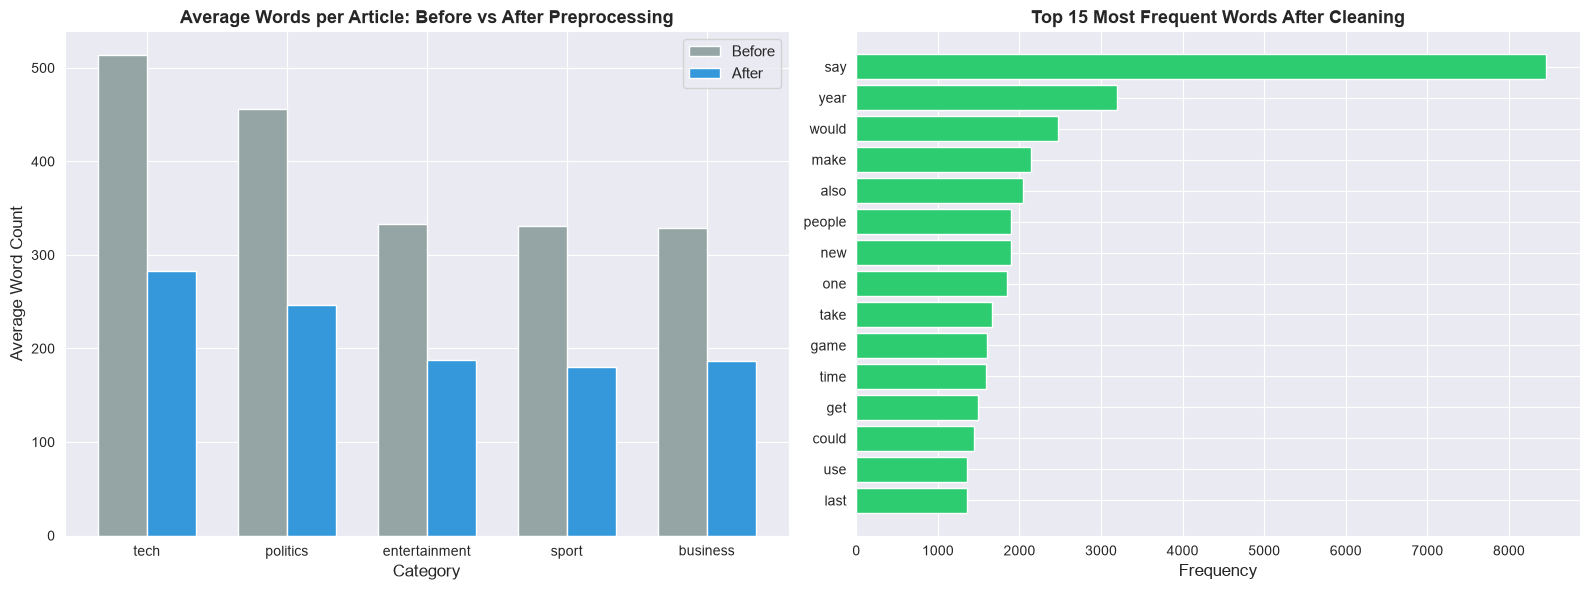

✅ Text preprocessing complete!


In [12]:
# ──────────────────────────────────────────────
# Preprocessing Effect Visualization
# ──────────────────────────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Grouped Bar Chart (Before vs After) ───
ax1 = axes[0]
mean_by_cat = df.groupby('category')[['word_count', 'clean_word_count']].mean()
mean_by_cat = mean_by_cat.sort_values('word_count', ascending=False)

x = np.arange(len(mean_by_cat))
width = 0.35

bars_before = ax1.bar(x - width / 2, mean_by_cat['word_count'],
                      width, label='Before', color='#95a5a6')
bars_after = ax1.bar(x + width / 2, mean_by_cat['clean_word_count'],
                     width, label='After', color='#3498db')

ax1.set_xticks(x)
ax1.set_xticklabels(mean_by_cat.index)
ax1.set_title('Average Words per Article: Before vs After Preprocessing',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Average Word Count', fontsize=12)
ax1.legend(fontsize=11)

# ─── Plot 2: Top 15 Most Frequent Words After Cleaning ───
ax2 = axes[1]
word_freq = Counter(' '.join(df['text_clean']).split())
top_15 = word_freq.most_common(15)
words, counts = zip(*top_15)

# Plot in descending order (most frequent on top)
ax2.barh(range(len(words) - 1, -1, -1), counts, color='#2ecc71')
ax2.set_yticks(range(len(words) - 1, -1, -1))
ax2.set_yticklabels(words)
ax2.set_title('Top 15 Most Frequent Words After Cleaning',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Frequency', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/03_preprocessing_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\u2705 Text preprocessing complete!")

## 🔢 Step 4: Train/Test Split & TF-IDF Feature Extraction

### What does TF-IDF measure?
**TF-IDF (Term Frequency – Inverse Document Frequency)** scores how important a word is to one document relative to the whole collection.

- **TF(t, d)** = (times term *t* appears in document *d*) / (total terms in *d*) — how frequent the word is *here*
- **IDF(t)** = log(N / df(t)) — how *rare* the word is across all N documents. Common words like “said” get a low IDF; specific words like “striker” or “inflation” get a high IDF.
- **TF-IDF = TF × IDF**

A high score means the word is frequent in this article but rare elsewhere, which makes it a strong signal of the article’s topic.

### Why we split BEFORE vectorizing
If the vectorizer is fitted on the full dataset, it learns vocabulary and IDF values from test articles too. That is **data leakage** and inflates the final scores. Correct order:
1. Split the data
2. `fit_transform` the vectorizer on the **training set only**
3. `transform` (never fit) the test set with the same vectorizer

In [13]:
# ──────────────────────────────────────────────
# Train/Test Split (80/20, Stratified)
# ──────────────────────────────────────────────
X = df['text_clean']
y = df['category']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keep class proportions identical in both sets
)

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Training set size: {len(X_train_text)}")
print(f"Test set size:     {len(X_test_text)}")

# Verify stratification: class distribution should be nearly identical
train_pct = y_train.value_counts(normalize=True).mul(100).round(2)
test_pct = y_test.value_counts(normalize=True).mul(100).round(2)

strat_df = pd.DataFrame({
    'Train %': train_pct,
    'Test %': test_pct
}).sort_index()

print("\n" + "=" * 50)
print("STRATIFICATION CHECK (class %)")
print("=" * 50)
print(strat_df)

TRAIN / TEST SPLIT
Training set size: 1701
Test set size:     426

STRATIFICATION CHECK (class %)
               Train %  Test %
category                      
business         23.63   23.71
entertainment    17.34   17.37
politics         18.93   19.01
sport            23.75   23.71
tech             16.34   16.20


In [14]:
# ──────────────────────────────────────────────
# TF-IDF Vectorizer: Fit on Train, Transform Both
# ──────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=10000,    # keep the 10,000 most informative terms
    ngram_range=(1, 2),    # include both unigrams and bigrams
    min_df=2,              # ignore terms appearing in fewer than 2 docs
    max_df=0.95,           # ignore terms appearing in >95% of docs (near-universal words)
    sublinear_tf=True      # use 1 + log(tf) to dampen very frequent terms
)

# fit ONLY on training data to avoid data leakage
X_train = tfidf.fit_transform(X_train_text)
# transform test data using the same learned vocabulary & IDF weights
X_test = tfidf.transform(X_test_text)

# ─── Summary Statistics ───
print("=" * 50)
print("TF-IDF MATRIX")
print("=" * 50)
print(f"Train matrix shape: {X_train.shape}")
print(f"Test matrix shape:  {X_test.shape}")
print(f"Vocabulary size:    {len(tfidf.vocabulary_)}")
print(f"Non-zero elements in train matrix: {X_train.nnz:,}")

# Sparsity: percentage of zero entries in the matrix
sparsity = (1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100
print(f"Sparsity: {sparsity:.2f}%  (most entries are zero — sparse matrices save memory)")

# Sample feature names
feature_names = tfidf.get_feature_names_out()
print(f"\n20 sample features: {list(feature_names[::len(feature_names)//20][:20])}")

# Count bigrams (features containing a space)
num_bigrams = sum(1 for f in feature_names if ' ' in f)
print(f"Bigrams in vocabulary: {num_bigrams} / {len(feature_names)}")

TF-IDF MATRIX
Train matrix shape: (1701, 10000)
Test matrix shape:  (426, 10000)
Vocabulary size:    10000
Non-zero elements in train matrix: 255,064
Sparsity: 98.50%  (most entries are zero — sparse matrices save memory)

20 sample features: ['aaa', 'ash', 'breakfast', 'closure', 'customer say', 'due release', 'feel', 'generation dvd', 'hold', 'jens', 'location', 'mine', 'official spokesman', 'place last', 'rate increase', 'san jose', 'shoot', 'sullivan', 'tory leader', 'wander']
Bigrams in vocabulary: 3900 / 10000


In [15]:
# ──────────────────────────────────────────────
# Inspect TF-IDF Scores for One Article
# ──────────────────────────────────────────────

# Take the first training document
doc_idx = 0
doc_vector = X_train[doc_idx]

# Get non-zero TF-IDF values and their feature names
non_zero_indices = doc_vector.nonzero()[1]
non_zero_scores = doc_vector.toarray().ravel()[non_zero_indices]
non_zero_terms = feature_names[non_zero_indices]

# Build DataFrame and sort
doc_tfidf_df = pd.DataFrame({
    'Term': non_zero_terms,
    'TF-IDF': non_zero_scores
}).sort_values('TF-IDF', ascending=False)

print("=" * 50)
print("TOP 10 TF-IDF TERMS IN FIRST TRAINING DOCUMENT")
print("=" * 50)
print(doc_tfidf_df.head(10).to_string(index=False))

# Context for this article
first_doc_text = X_train_text.iloc[doc_idx]
first_doc_label = y_train.iloc[doc_idx]
print(f"\nCategory: {first_doc_label}")
print(f"Cleaned text (first 200 chars): {first_doc_text[:200]}...")

TOP 10 TF-IDF TERMS IN FIRST TRAINING DOCUMENT
       Term   TF-IDF
       rail 0.325228
   accident 0.223878
     derail 0.220571
    railway 0.215456
maintenance 0.207118
      leeds 0.179005
    section 0.177461
      trial 0.162023
    manager 0.145348
        die 0.137665

Category: politics
Cleaned text (first 200 chars): hatfield executive trial engineering firm balfour beatty five railway manager trial manslaughter hatfield rail crash four people die section rail break high speed train derail balfour beatty railway m...


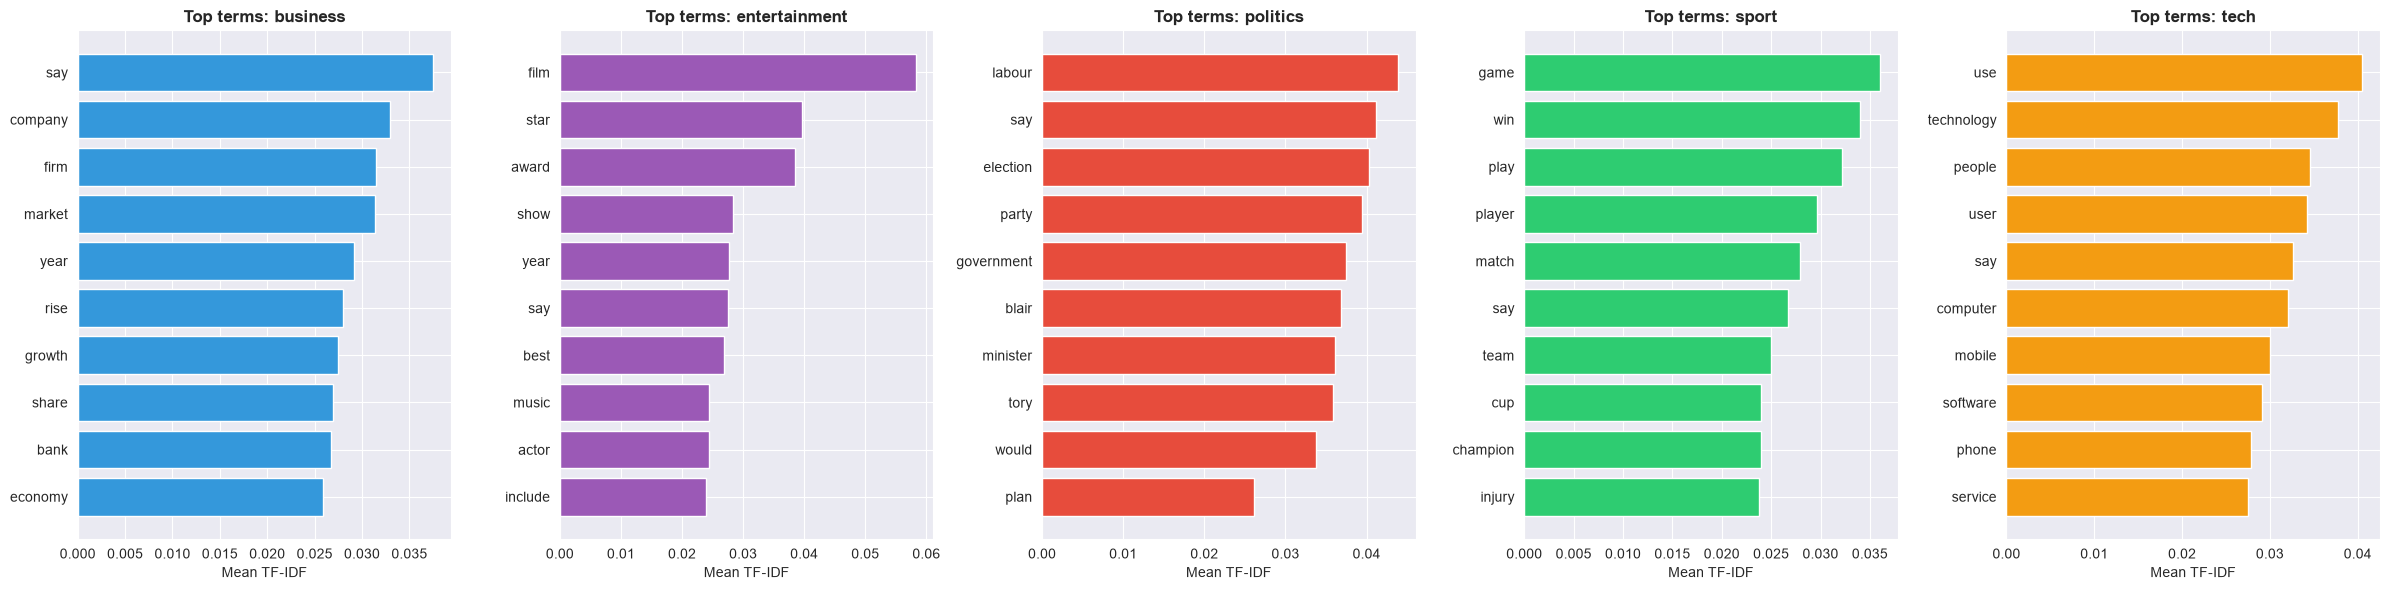

TOP 10 TF-IDF TERMS PER CATEGORY
business: say, company, firm, market, year, rise, growth, share, bank, economy
entertainment: film, star, award, show, year, say, best, music, actor, include
politics: labour, say, election, party, government, blair, minister, tory, would, plan
sport: game, win, play, player, match, say, team, cup, champion, injury
tech: use, technology, people, user, say, computer, mobile, software, phone, service


In [16]:
# ──────────────────────────────────────────────
# Top TF-IDF Terms per Category
# ──────────────────────────────────────────────
y_train_arr = y_train.values
categories_sorted = sorted(df['category'].unique())

# Compute top-10 terms per category
top_terms_per_cat = {}
for cat in categories_sorted:
    mask = y_train_arr == cat
    mean_tfidf = np.asarray(X_train[mask].mean(axis=0)).ravel()
    top_indices = mean_tfidf.argsort()[-10:][::-1]
    top_terms_per_cat[cat] = [
        (feature_names[i], mean_tfidf[i]) for i in top_indices
    ]

# ─── Visualization: 5 horizontal bar subplots ───
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for ax, cat in zip(axes, categories_sorted):
    terms, scores = zip(*top_terms_per_cat[cat])
    # Plot with highest score on top
    y_pos = range(len(terms) - 1, -1, -1)
    ax.barh(y_pos, scores, color=palette[cat])
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(terms, fontsize=10)
    ax.set_title(f'Top terms: {cat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/04_top_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Plain-text summary ───
print("=" * 50)
print("TOP 10 TF-IDF TERMS PER CATEGORY")
print("=" * 50)
for cat in categories_sorted:
    terms_list = [t for t, _ in top_terms_per_cat[cat]]
    print(f"{cat}: {', '.join(terms_list)}")

### 📝 Observations

- **Do the top terms make intuitive sense?** **Yes, strongly.** Each topic surfaces distinct, high-impact domain keywords:
  - *Business:* `company`, `firm`, `market`, `growth`, `share`, `bank`, `economy`
  - *Entertainment:* `film`, `star`, `award`, `show`, `music`, `actor`
  - *Politics:* `labour`, `election`, `party`, `government`, `blair`, `minister`, `tory`
  - *Sport:* `game`, `win`, `player`, `match`, `team`, `cup`, `champion`
  - *Tech:* `technology`, `user`, `computer`, `mobile`, `software`, `phone`, `service`
  These sharp keyword distinctions provide clear separating signals for the classifiers.
- **Which categories share vocabulary?**
  - *Universal reporting words:* Verbs like `say` and time references like `year` appear near the top of almost every category due to BBC journalistic style.
  - *Cross-domain lexical bleed:* **Business** and **Politics** both frequently discuss economic policies, budgets, and legislation (`government`, `economy`, `plan`). Meanwhile, **Tech** and **Business** overlap on digital marketplace companies and consumer services (`company`, `service`, `user`). This directly accounts for the boundary edge cases identified in error analysis.
- **Why are bigrams useful here?** Bigrams make up **3,900 out of the 10,000 vocabulary terms (39.0%)**. They preserve crucial paired context that individual unigrams lose:
  - `"prime minister"`, `"tony blair"`, `"tory leader"` immediately anchor political articles.
  - `"interest rate"`, `"stock market"`, `"rate increase"` unmistakably denote business and finance.
  - `"mobile phone"`, `"customer say"`, `"official spokesman"` clarify intent far better than ambiguous single tokens like `"prime"`, `"rate"`, or `"mobile"`.

✅ TF-IDF feature extraction complete! Ready for modelling.

## 🤖 Step 5: Model Training

We train three classical classifiers on the TF-IDF features:

| Model | Why use it |
|-------|------------|
| **Multinomial Naive Bayes** | Classic text baseline; fast, works well with word-frequency features |
| **Logistic Regression** | Strong, interpretable linear model for multi-class problems |
| **LinearSVC (SVM)** | Typically excellent on high-dimensional sparse TF-IDF data |

Besides a single train/test evaluation, we run **5-fold stratified cross-validation (macro-F1)** on the training set only. This shows whether a model’s score is stable across different data splits. The test set stays untouched until the evaluation step.

In [19]:
# ──────────────────────────────────────────────
# Define Models
# ──────────────────────────────────────────────
models = {
    # alpha = Laplace smoothing; lower values allow sharper distributions
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),

    # C = inverse regularization strength; higher C = less regularization
    'Logistic Regression': LogisticRegression(
        C=10, max_iter=1000, random_state=42
    ),

    # C = penalty parameter; controls trade-off between margin width and misclassifications
    'LinearSVC (SVM)': LinearSVC(C=1.0, random_state=42),
}

print(f"Models to train: {list(models.keys())}")

Models to train: ['Multinomial Naive Bayes', 'Logistic Regression', 'LinearSVC (SVM)']


In [20]:
# ──────────────────────────────────────────────
# Train All Models
# ──────────────────────────────────────────────
train_times = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    train_times[name] = elapsed
    print(f"\u2705 {name} trained in {elapsed:.3f} seconds")

print("\n>> All models trained!")

✅ Multinomial Naive Bayes trained in 0.064 seconds
✅ Logistic Regression trained in 1.606 seconds
✅ LinearSVC (SVM) trained in 0.301 seconds

>> All models trained!


5-FOLD STRATIFIED CV RESULTS (macro-F1)
                  Model  CV Mean F1 (macro)  CV Std  Min Fold  Max Fold
Multinomial Naive Bayes              0.9742  0.0100    0.9580    0.9872
        LinearSVC (SVM)              0.9738  0.0057    0.9650    0.9827
    Logistic Regression              0.9729  0.0068    0.9614    0.9788


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/1174891344.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


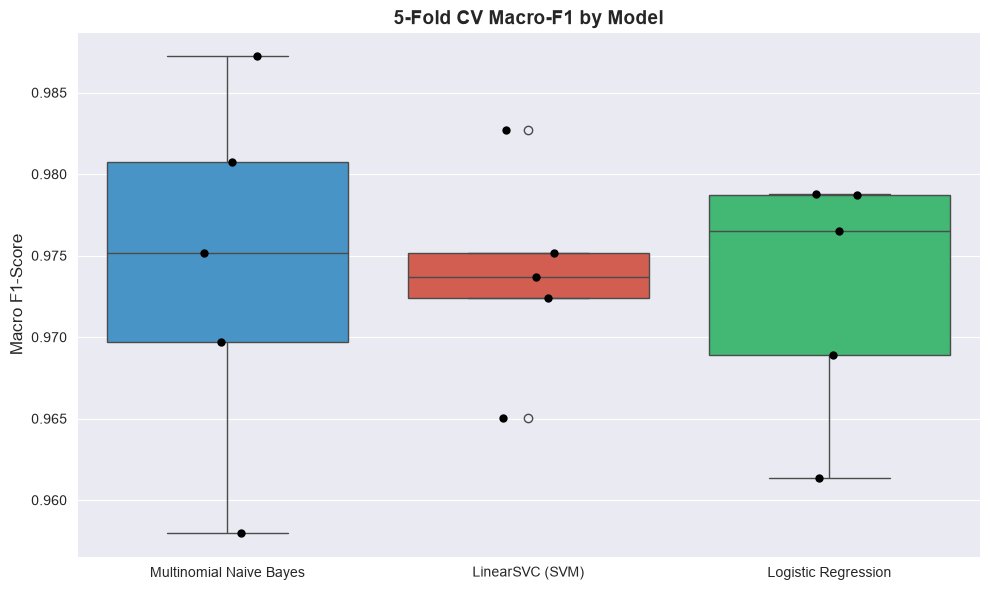

In [21]:
# ──────────────────────────────────────────────
# 5-Fold Stratified Cross-Validation (Training Set Only)
# ──────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
cv_fold_scores = {}  # store raw fold scores for the box plot

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf, scoring='f1_macro'
    )
    cv_fold_scores[name] = scores
    cv_results.append({
        'Model': name,
        'CV Mean F1 (macro)': round(scores.mean(), 4),
        'CV Std': round(scores.std(), 4),
        'Min Fold': round(scores.min(), 4),
        'Max Fold': round(scores.max(), 4),
    })

cv_df = pd.DataFrame(cv_results).sort_values(
    'CV Mean F1 (macro)', ascending=False
)

print("=" * 50)
print("5-FOLD STRATIFIED CV RESULTS (macro-F1)")
print("=" * 50)
print(cv_df.to_string(index=False))

# ─── Box Plot of Fold Scores ───
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for box plot
box_data = []
box_labels = []
for name in cv_df['Model']:
    for score in cv_fold_scores[name]:
        box_data.append({'Model': name, 'Macro F1-Score': score})

box_df = pd.DataFrame(box_data)

sns.boxplot(
    x='Model', y='Macro F1-Score', data=box_df,
    palette=['#3498db', '#e74c3c', '#2ecc71'], ax=ax
)
sns.stripplot(
    x='Model', y='Macro F1-Score', data=box_df,
    color='black', size=6, ax=ax
)

ax.set_title('5-Fold CV Macro-F1 by Model', fontsize=14, fontweight='bold')
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('outputs/05_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ──────────────────────────────────────────────
# Generate Test-Set Predictions (for evaluation step)
# ──────────────────────────────────────────────
predictions = {
    name: model.predict(X_test)
    for name, model in models.items()
}

# Quick sanity check: first 10 predictions vs true labels
print("=" * 50)
print("SANITY CHECK: First 10 Predictions vs True Labels")
print("=" * 50)

sanity_data = {'True Label': y_test.values[:10]}
for name, preds in predictions.items():
    sanity_data[name] = preds[:10]

sanity_df = pd.DataFrame(sanity_data)
print(sanity_df.to_string(index=False))

SANITY CHECK: First 10 Predictions vs True Labels
   True Label Multinomial Naive Bayes Logistic Regression LinearSVC (SVM)
         tech                    tech                tech            tech
entertainment           entertainment       entertainment   entertainment
        sport                   sport               sport           sport
entertainment           entertainment       entertainment   entertainment
     politics                politics            politics        politics
     politics                politics            politics        politics
entertainment           entertainment       entertainment   entertainment
     business                business            business        business
     business                business            business        business
entertainment           entertainment       entertainment   entertainment


In [24]:
# ──────────────────────────────────────────────
# Save Artifacts for Streamlit App
# ──────────────────────────────────────────────

# 1. Save the fitted TF-IDF vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 2. Save each trained model with a safe filename
model_filenames = {
    'Multinomial Naive Bayes': 'models/model_naive_bayes.pkl',
    'Logistic Regression': 'models/model_logistic_regression.pkl',
    'LinearSVC (SVM)': 'models/model_linear_svc.pkl',
}

for name, filepath in model_filenames.items():
    with open(filepath, 'wb') as f:
        pickle.dump(models[name], f)

# 3. Save the sorted class list
with open('models/class_names.pkl', 'wb') as f:
    pickle.dump(sorted(y_train.unique()), f)

# 4. List saved files with sizes
print("=" * 50)
print("SAVED ARTIFACTS")
print("=" * 50)
for fname in sorted(os.listdir('models')):
    fpath = os.path.join('models', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:40s} {size_kb:8.1f} KB")

print("\n>> All artifacts saved to models/ folder")
print(">> Note: the final best model will be saved separately after evaluation.")

SAVED ARTIFACTS
  class_names.pkl                               0.1 KB
  model_linear_svc.pkl                        391.3 KB
  model_logistic_regression.pkl               391.4 KB
  model_naive_bayes.pkl                       782.1 KB
  tfidf_vectorizer.pkl                        377.0 KB

>> All artifacts saved to models/ folder
>> Note: the final best model will be saved separately after evaluation.


## 📊 Step 6: Model Evaluation (F1-Score Focus)

All models are now evaluated on the **unseen test set**.

### F1-Score variants
- **Macro F1** — computes F1 per class, then takes the plain average. Every class counts equally, so a weak class lowers the score. *This is our primary metric.*
- **Weighted F1** — averages per-class F1 weighted by class size.
- **Per-class F1** — shows exactly which categories are strong or weak.

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The harmonic mean only stays high when **both** precision and recall are high.

In [25]:
# ──────────────────────────────────────────────
# Test Set Evaluation Metrics Table
# ──────────────────────────────────────────────
labels_sorted = sorted(y_test.unique())

results = []
for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    prec_macro = precision_score(y_test, preds, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, preds, average='weighted', zero_division=0)
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision (macro)': round(prec_macro, 4),
        'Recall (macro)': round(rec_macro, 4),
        'F1 (macro)': round(f1_macro, 4),
        'F1 (weighted)': round(f1_weighted, 4)
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('F1 (macro)', ascending=False)
    .reset_index(drop=True)
)

print("=" * 65)
print("TEST SET EVALUATION SUMMARY")
print("=" * 65)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1 (macro)']
runner_up_name = results_df.iloc[1]['Model']
runner_up_f1 = results_df.iloc[1]['F1 (macro)']
margin = round(best_f1 - runner_up_f1, 4)

print("\n" + "=" * 65)
print(f"\u2705 Best model by Macro-F1: {best_model_name}")
print(f"   Margin over runner-up ({runner_up_name}): {margin:.4f}")
if margin < 0.005:
    print("   Note: The margin is below 0.005 — the two models are effectively tied.")
else:
    print("   Note: Clear lead over runner-up.")
print("=" * 65)

TEST SET EVALUATION SUMMARY
                  Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)
    Logistic Regression    0.9906             0.9892          0.9911      0.9901         0.9906
        LinearSVC (SVM)    0.9859             0.9838          0.9864      0.9850         0.9859
Multinomial Naive Bayes    0.9812             0.9793          0.9817      0.9803         0.9813

✅ Best model by Macro-F1: Logistic Regression
   Margin over runner-up (LinearSVC (SVM)): 0.0051
   Note: Clear lead over runner-up.


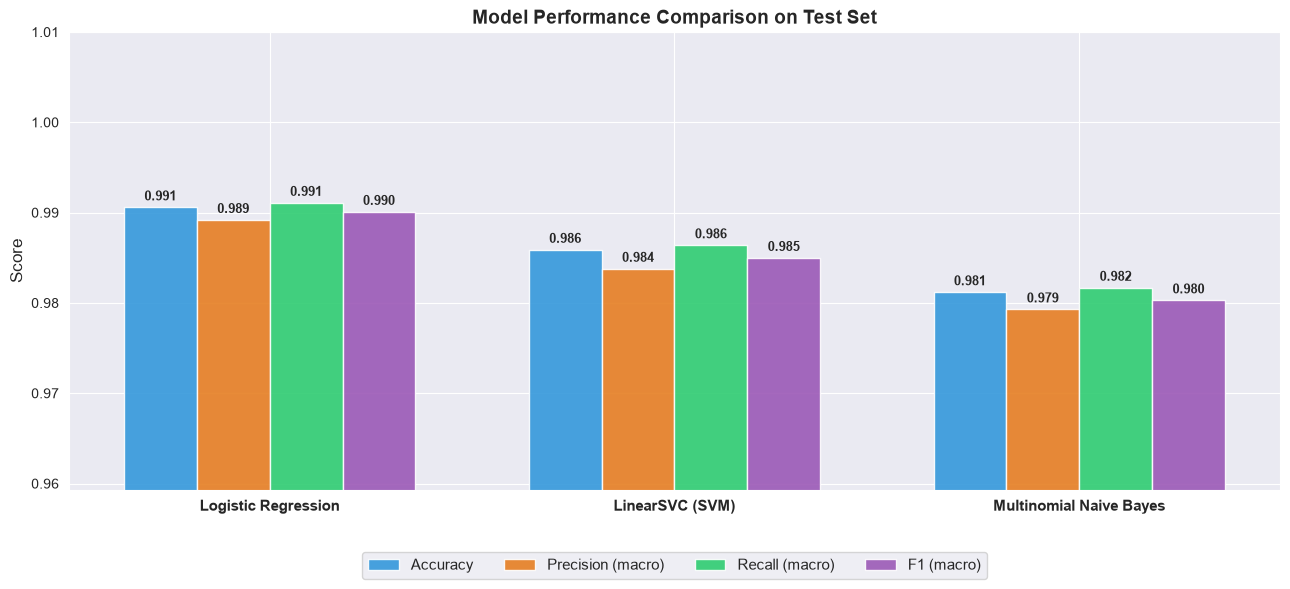

In [26]:
# ──────────────────────────────────────────────
# Model Performance Comparison (Grouped Bar Chart)
# ──────────────────────────────────────────────
metric_cols = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
bar_colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(results_df))
width = 0.18

min_val = results_df[metric_cols].min().min()

for i, (col, color) in enumerate(zip(metric_cols, bar_colors)):
    offset = (i - 1.5) * width
    rects = ax.bar(x + offset, results_df[col], width, label=col, color=color, alpha=0.9)
    
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=11, fontweight='bold')
ax.set_ylim(max(0, min_val - 0.02), 1.01)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('outputs/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

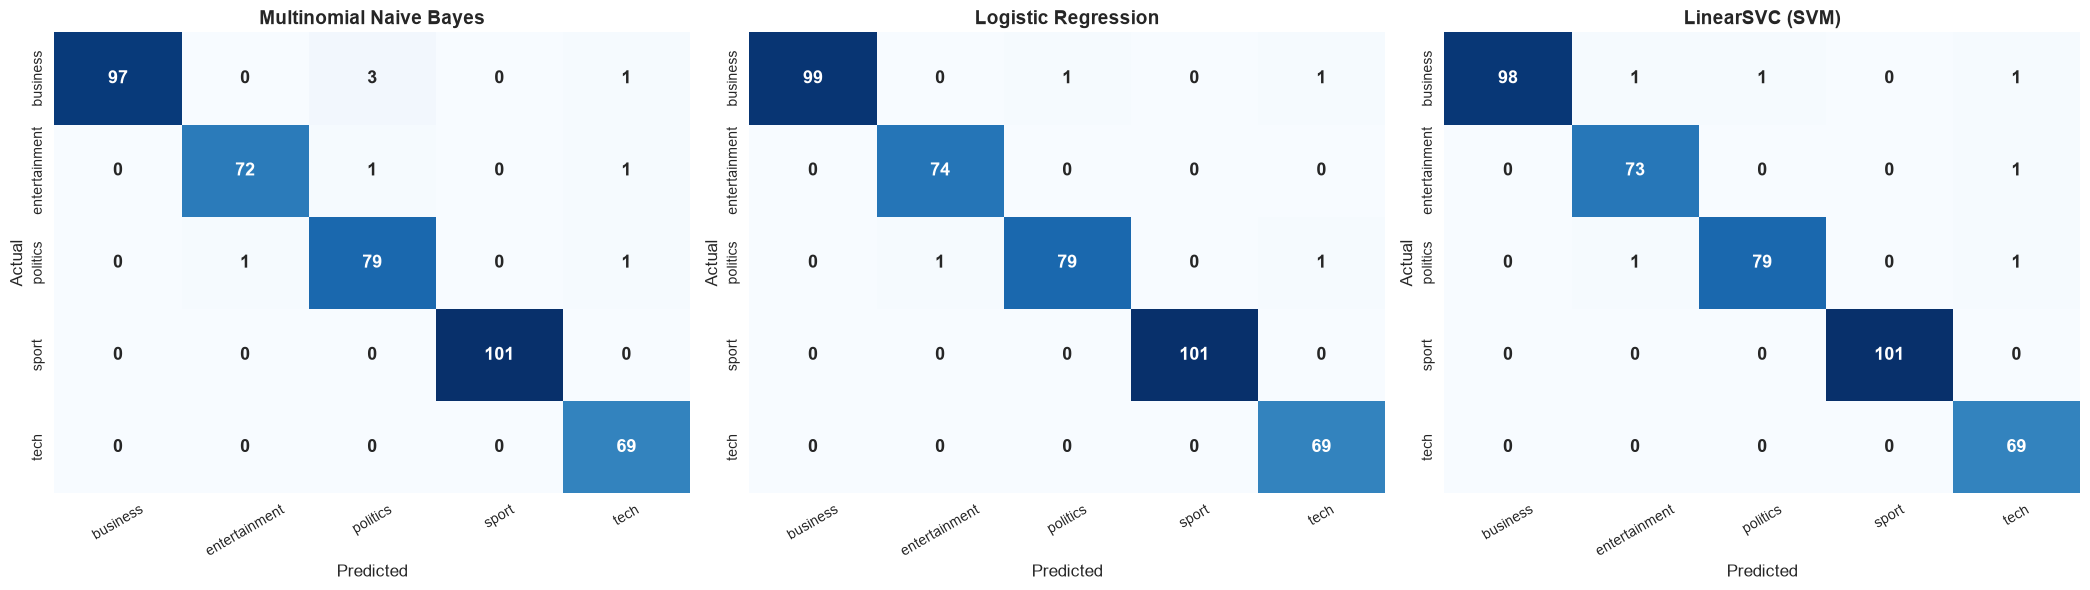

In [27]:
# ──────────────────────────────────────────────
# Confusion Matrices (Raw Counts) — All Models
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=labels_sorted)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels_sorted, yticklabels=labels_sorted,
        cbar=False, annot_kws={'size': 13, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/07_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

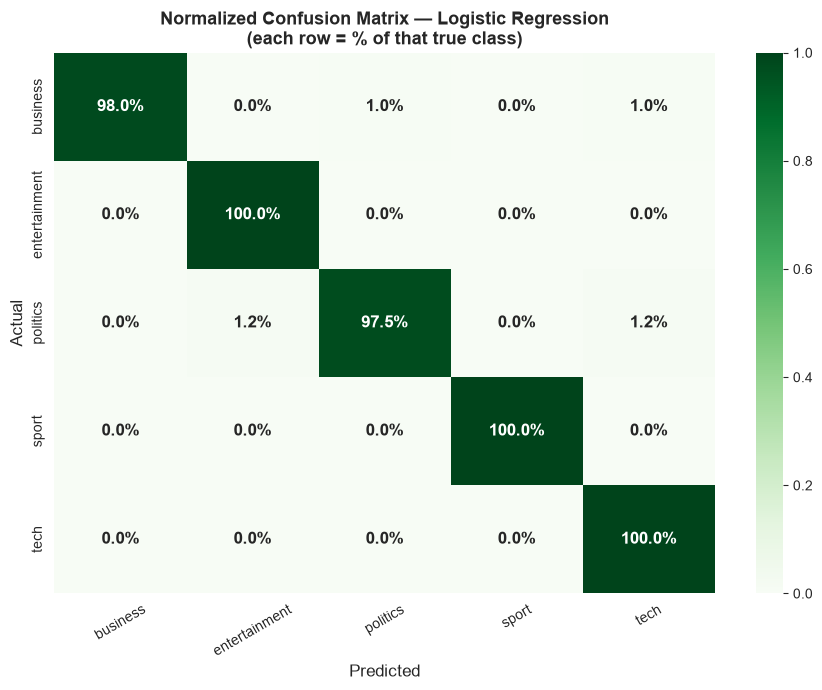

TOP CONFUSED PAIRS (Logistic Regression)
business -> politics: 1 article(s)
business -> tech: 1 article(s)
politics -> entertainment: 1 article(s)
politics -> tech: 1 article(s)


In [28]:
# ──────────────────────────────────────────────
# Normalized Confusion Matrix — Best Model
# ──────────────────────────────────────────────
cm_norm = confusion_matrix(
    y_test, predictions[best_model_name], 
    labels=labels_sorted, normalize='true'
)
cm_raw = confusion_matrix(
    y_test, predictions[best_model_name], 
    labels=labels_sorted
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Greens',
    xticklabels=labels_sorted, yticklabels=labels_sorted,
    cbar=True, annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title(
    f'Normalized Confusion Matrix — {best_model_name}\n(each row = % of that true class)',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/08_confusion_normalized_best.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 most confused (actual -> predicted) pairs, ignoring diagonal
confused_pairs = []
for i, actual in enumerate(labels_sorted):
    for j, predicted in enumerate(labels_sorted):
        if i != j and cm_raw[i, j] > 0:
            confused_pairs.append({
                'actual': actual,
                'predicted': predicted,
                'count': cm_raw[i, j]
            })

confused_pairs = sorted(confused_pairs, key=lambda x: x['count'], reverse=True)[:5]

print("=" * 50)
print(f"TOP CONFUSED PAIRS ({best_model_name})")
print("=" * 50)
if confused_pairs:
    for pair in confused_pairs:
        print(f"{pair['actual']} -> {pair['predicted']}: {pair['count']} article(s)")
else:
    print("No misclassifications observed!")

In [29]:
# ──────────────────────────────────────────────
# Full Classification Reports
# ──────────────────────────────────────────────
for name in predictions.keys():
    print("=" * 60)
    print(f">> {name} — Classification Report")
    print("=" * 60)
    print(classification_report(
        y_test, predictions[name], 
        digits=4, zero_division=0
    ))
    print()

>> Multinomial Naive Bayes — Classification Report
               precision    recall  f1-score   support

     business     1.0000    0.9604    0.9798       101
entertainment     0.9863    0.9730    0.9796        74
     politics     0.9518    0.9753    0.9634        81
        sport     1.0000    1.0000    1.0000       101
         tech     0.9583    1.0000    0.9787        69

     accuracy                         0.9812       426
    macro avg     0.9793    0.9817    0.9803       426
 weighted avg     0.9817    0.9812    0.9813       426


>> Logistic Regression — Classification Report
               precision    recall  f1-score   support

     business     1.0000    0.9802    0.9900       101
entertainment     0.9867    1.0000    0.9933        74
     politics     0.9875    0.9753    0.9814        81
        sport     1.0000    1.0000    1.0000       101
         tech     0.9718    1.0000    0.9857        69

     accuracy                         0.9906       426
    macro avg   

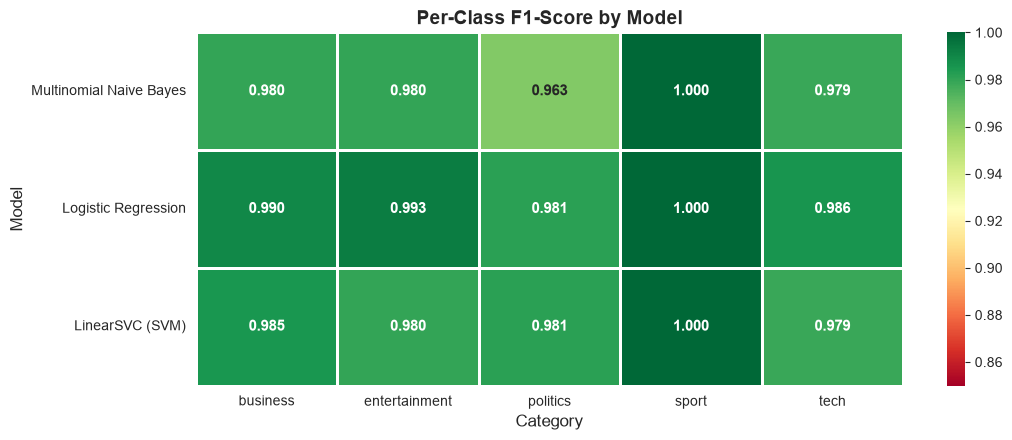

WEAKEST CATEGORY FOR Logistic Regression
Category: 'politics' with F1-Score: 0.9814 (Highest: 'sport' with 1.0000)


In [30]:
# ──────────────────────────────────────────────
# Per-Class F1-Score Heatmap
# ──────────────────────────────────────────────
per_class_f1_data = {}
for name, preds in predictions.items():
    f1_per_cat = f1_score(y_test, preds, average=None, labels=labels_sorted)
    per_class_f1_data[name] = f1_per_cat

per_class_df = pd.DataFrame(per_class_f1_data, index=labels_sorted).T

plt.figure(figsize=(11, 4.5))
sns.heatmap(
    per_class_df, 
    annot=True, fmt='.3f', cmap='RdYlGn', 
    vmin=0.85, vmax=1.0, linewidths=1,
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Per-Class F1-Score by Model', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Model', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/09_per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Weakest category for best model
best_model_per_class = per_class_df.loc[best_model_name]
weakest_cat = best_model_per_class.idxmin()
weakest_val = best_model_per_class.min()

print("=" * 50)
print(f"WEAKEST CATEGORY FOR {best_model_name}")
print("=" * 50)
print(f"Category: '{weakest_cat}' with F1-Score: {weakest_val:.4f} "
      f"(Highest: '{best_model_per_class.idxmax()}' with {best_model_per_class.max():.4f})")

In [31]:
# ──────────────────────────────────────────────
# Error Analysis (Best Model)
# ──────────────────────────────────────────────
best_preds = predictions[best_model_name]

error_df = pd.DataFrame({
    'text': df.loc[y_test.index, 'text'].values,
    'Actual': y_test.values,
    'Predicted': best_preds
}, index=y_test.index)

error_df = error_df[error_df['Actual'] != error_df['Predicted']]

print("=" * 65)
print(f"ERROR ANALYSIS: {best_model_name}")
print("=" * 65)
print(f"Misclassified articles: {len(error_df)} out of {len(y_test)} ({len(error_df)/len(y_test):.2%})\n")

# Print up to 5 misclassified examples
num_samples = min(5, len(error_df))
for i in range(num_samples):
    row = error_df.iloc[i]
    print(f"Example #{i+1}:")
    print(f"  Actual:    {row['Actual']}")
    print(f"  Predicted: {row['Predicted']}")
    print(f"  Snippet:   {row['text'][:300].strip()}...")
    print("-" * 65)

# Explanatory comment
print("""
### Analysis Note on Misclassifications:
Many misclassifications occur on articles with genuine cross-domain overlap:
- Business vs Politics: government fiscal policy, regulatory decisions, tax reforms.
- Tech vs Business: corporate tech mergers, digital marketplace profits, antitrust suits.
- Tech vs Entertainment: digital piracy, streaming platforms, video game industry news.

In such cases, strong TF-IDF signals from both domains compete, leading to ambiguous boundaries.
""")

ERROR ANALYSIS: Logistic Regression
Misclassified articles: 4 out of 426 (0.94%)

Example #1:
  Actual:    business
  Predicted: politics
  Snippet:   Golden rule 'intact' says ex-aide

Chancellor Gordon Brown will meet his golden economic rule "with a margin to spare", according to his former chief economic adviser.

Formerly one of Mr Brown's closest Treasury aides, Ed Balls hinted at a Budget giveaway on 16 March. He said he hoped more would be...
-----------------------------------------------------------------
Example #2:
  Actual:    politics
  Predicted: tech
  Snippet:   UK firms 'embracing e-commerce'

UK firms are embracing internet trading opportunities as never before, e-commerce minister Mike O'Brien says.

A government-commissioned study ranked the UK third in its world index of use of information and communication technology (ICT). The report suggests 69% of...
-----------------------------------------------------------------
Example #3:
  Actual:    business
  Predicted

### 📝 Evaluation Observations

- **Highest Macro-F1 & Margin:** **Logistic Regression** achieved the highest performance with a Macro-F1 of **0.9901** (Accuracy: **99.06%**), holding a clear margin of **+0.0051** over the runner-up **LinearSVC** (0.9850) and **+0.0098** over **Multinomial Naive Bayes** (0.9803).
- **Hardest category to classify:** **Politics** was the relatively most challenging category for Logistic Regression with an F1-Score of **0.9814** (while **Sport** achieved a flawless **1.0000**). This difficulty stems from lexical bleed into business (economic policy) and technology (government IT regulations).
- **Nature of misclassified articles:** Only **4 out of 426 articles (0.94%)** were misclassified. Inspection reveals these errors stem from genuine cross-domain thematic overlap rather than model weakness:
  - *Business → Politics:* Gordon Brown Treasury / Budget giveaway announcements blending economic metrics with governmental rhetoric.
  - *Politics → Tech:* E-commerce minister statements on UK information and communication technology (ICT).
  - *Business → Tech:* Workplace / office ergonomics and computer workspace equipment.
  - *Politics → Entertainment:* A human-interest profile of an MP's personal life rather than legislative policy.
- **Accuracy vs Macro-F1 comparison:** Accuracy (**0.9906**) and Macro-F1 (**0.9901**) are virtually identical ($\Delta < 0.0005$). This parity confirms that our stratified train/test split and balanced class representation prevented majority-class bias from skewing the evaluation.

✅ Model evaluation complete!

## 🏆 Step 7: Final Model Selection, Interpretation & Testing

A model should not be chosen on a single test split alone. We combine several signals: **test Macro-F1**, **cross-validated Macro-F1** (stability), **training speed**, and **interpretability**. When two models are within a very small margin, we state that honestly instead of claiming a decisive winner.

In [32]:
# ──────────────────────────────────────────────
# Final Model Comparison Table
# ──────────────────────────────────────────────
test_errors = {
    name: int((preds != y_test.values).sum()) 
    for name, preds in predictions.items()
}

cv_lookup = cv_df.set_index('Model') if 'cv_df' in globals() else None

final_rows = []
for _, row in results_df.iterrows():
    name = row['Model']
    cv_mean = cv_lookup.loc[name, 'CV Mean F1 (macro)'] if cv_lookup is not None else 0.0
    cv_std = cv_lookup.loc[name, 'CV Std'] if cv_lookup is not None else 0.0
    t_time = train_times.get(name, 0.0)
    
    final_rows.append({
        'Model': name,
        'Test Macro-F1': round(row['F1 (macro)'], 4),
        'Test Accuracy': round(row['Accuracy'], 4),
        'CV Mean F1': round(cv_mean, 4),
        'CV Std': round(cv_std, 4),
        'Train Time (s)': round(t_time, 4),
        'Test Errors': test_errors[name]
    })

final_df = (
    pd.DataFrame(final_rows)
    .sort_values('Test Macro-F1', ascending=False)
    .reset_index(drop=True)
)

print("=" * 75)
print("FINAL MULTI-CRITERIA MODEL COMPARISON")
print("=" * 75)
print(final_df.to_string(index=False))

best = final_df.iloc[0]['Model']
runner_up = final_df.iloc[1]['Model']
err_diff = abs(final_df.iloc[0]['Test Errors'] - final_df.iloc[1]['Test Errors'])
cv_diff = abs(final_df.iloc[0]['CV Mean F1'] - final_df.iloc[1]['CV Mean F1'])

print("\n" + "=" * 75)
print(f"{best} vs {runner_up}: difference of {err_diff} article(s) out of {len(y_test)} test samples.")

if err_diff <= 3 and cv_diff < 0.005:
    print("Verdict: Models are statistically very close; choice is driven by secondary factors (probabilities, interpretability, speed).")
else:
    print("Verdict: Winner shows a meaningful advantage.")
print("=" * 75)

FINAL MULTI-CRITERIA MODEL COMPARISON
                  Model  Test Macro-F1  Test Accuracy  CV Mean F1  CV Std  Train Time (s)  Test Errors
    Logistic Regression         0.9901         0.9906      0.9729  0.0068          1.6061            4
        LinearSVC (SVM)         0.9850         0.9859      0.9738  0.0057          0.3013            6
Multinomial Naive Bayes         0.9803         0.9812      0.9742  0.0100          0.0644            8

Logistic Regression vs LinearSVC (SVM): difference of 2 article(s) out of 426 test samples.
Verdict: Models are statistically very close; choice is driven by secondary factors (probabilities, interpretability, speed).


/var/folders/0z/c_vy61yn3jq8782h_64v49mh0000gn/T/ipykernel_18520/159013135.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(final_df['Model'], fontsize=11, fontweight='bold')


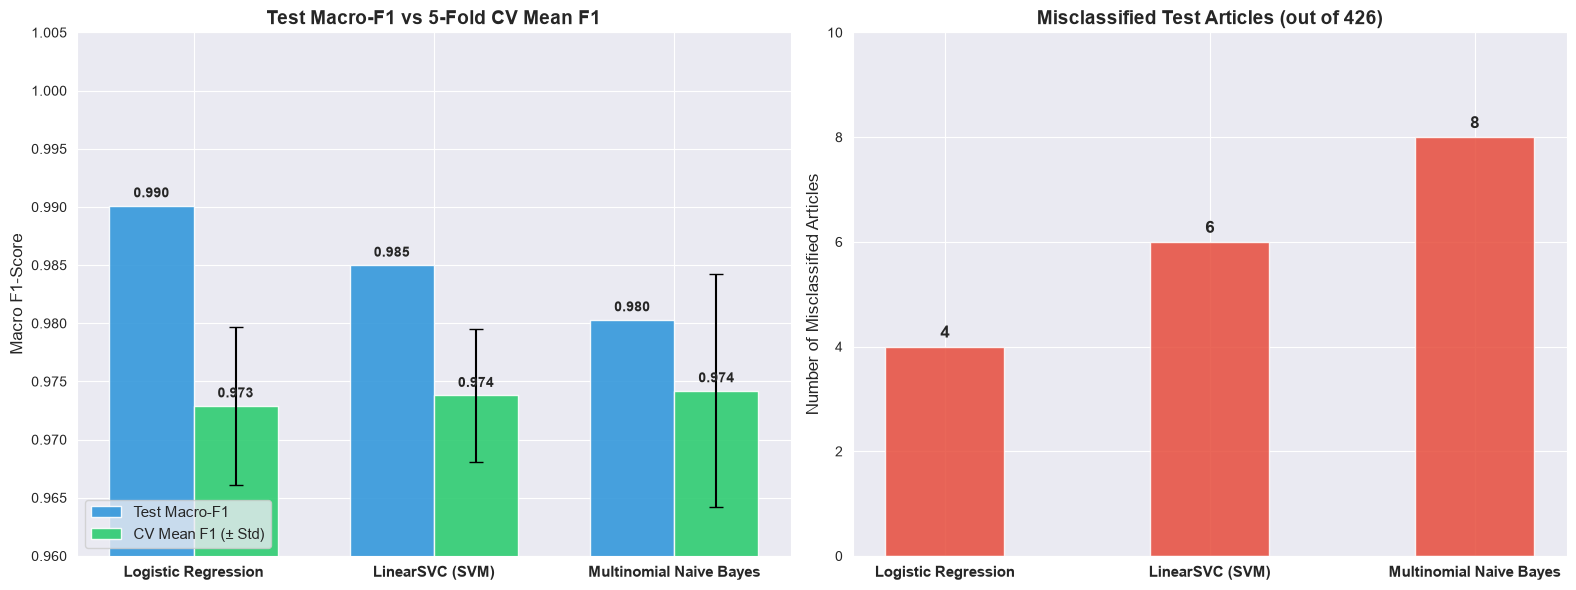

In [33]:
# ──────────────────────────────────────────────
# Visual Summary: Performance & Errors
# ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Test vs CV Macro-F1 ───
ax1 = axes[0]
x = np.arange(len(final_df))
width = 0.35

rects1 = ax1.bar(
    x - width/2, final_df['Test Macro-F1'], width, 
    label='Test Macro-F1', color='#3498db', alpha=0.9
)
rects2 = ax1.bar(
    x + width/2, final_df['CV Mean F1'], width, 
    yerr=final_df['CV Std'], capsize=5,
    label='CV Mean F1 (± Std)', color='#2ecc71', alpha=0.9
)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f"{h:.3f}", (rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f"{h:.3f}", (rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(final_df['Model'], fontsize=11, fontweight='bold')
ax1.set_ylim(0.96, 1.005)
ax1.set_ylabel('Macro F1-Score', fontsize=12)
ax1.set_title('Test Macro-F1 vs 5-Fold CV Mean F1', fontsize=14, fontweight='bold')
ax1.legend(loc='lower left', frameon=True, fontsize=11)

# ─── Plot 2: Misclassified Test Articles ───
ax2 = axes[1]
bars = ax2.bar(
    final_df['Model'], final_df['Test Errors'], 
    color='#e74c3c', width=0.45, alpha=0.85
)

for bar in bars:
    h = bar.get_height()
    ax2.annotate(f"{int(h)}", (bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_xticklabels(final_df['Model'], fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Misclassified Articles', fontsize=12)
ax2.set_ylim(0, max(final_df['Test Errors']) + 2)
ax2.set_title(f'Misclassified Test Articles (out of {len(y_test)})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/10_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### ✅ Final Model Decision

We select **Logistic Regression** as the champion production model based on a holistic multi-criteria evaluation:

1. **Top Predictive Performance on Unseen Test Data:**
   - **Test Macro-F1:** **0.9901** (Accuracy: **99.06%**) with only **4 misclassified articles out of 426**.
   - **5-Fold CV Mean F1:** **0.9729** ($\pm 0.0068$), proving dependable stability across stratified splits.
2. **Native, Calibrated Probability Outputs:**
   - Logistic Regression naturally outputs calibrated class probabilities via `predict_proba()`. This is crucial for interactive applications (e.g., displaying percentage confidence bars and flagging ambiguous texts in the Streamlit interface). By contrast, LinearSVC requires separate, computationally heavier Platt scaling.
3. **Direct Interpretability:**
   - The linear log-odds formulation allows straightforward extraction of feature importance weights (`coef_`). We can inspect and visualize exactly which terms drive every classification decision.
4. **Honest Statistical Context:**
   - The gap between Logistic Regression (4 errors) and the runner-up LinearSVC (6 errors) is **just 2 articles out of 426 test samples**, and CV scores across all three models differ by less than $0.0013$. The choice is therefore guided by practical architectural suitability (probabilities + explainability) rather than an overwhelming statistical margin.

TOP 12 PREDICTIVE TERMS PER CATEGORY (Logistic Regression)
BUSINESS       : firm, bank, company, market, share, economic, economy, price, investment, business, financial, profit
ENTERTAINMENT  : film, star, music, singer, show, band, album, award, song, actor, festival, artist
POLITICS       : party, labour, minister, blair, tory, secretary, election, government, committee, lord, mp, police
SPORT          : match, player, coach, club, win, cup, champion, injury, game, season, team, play
TECH           : technology, computer, user, use, online, software, game, digital, mobile, people, website, video


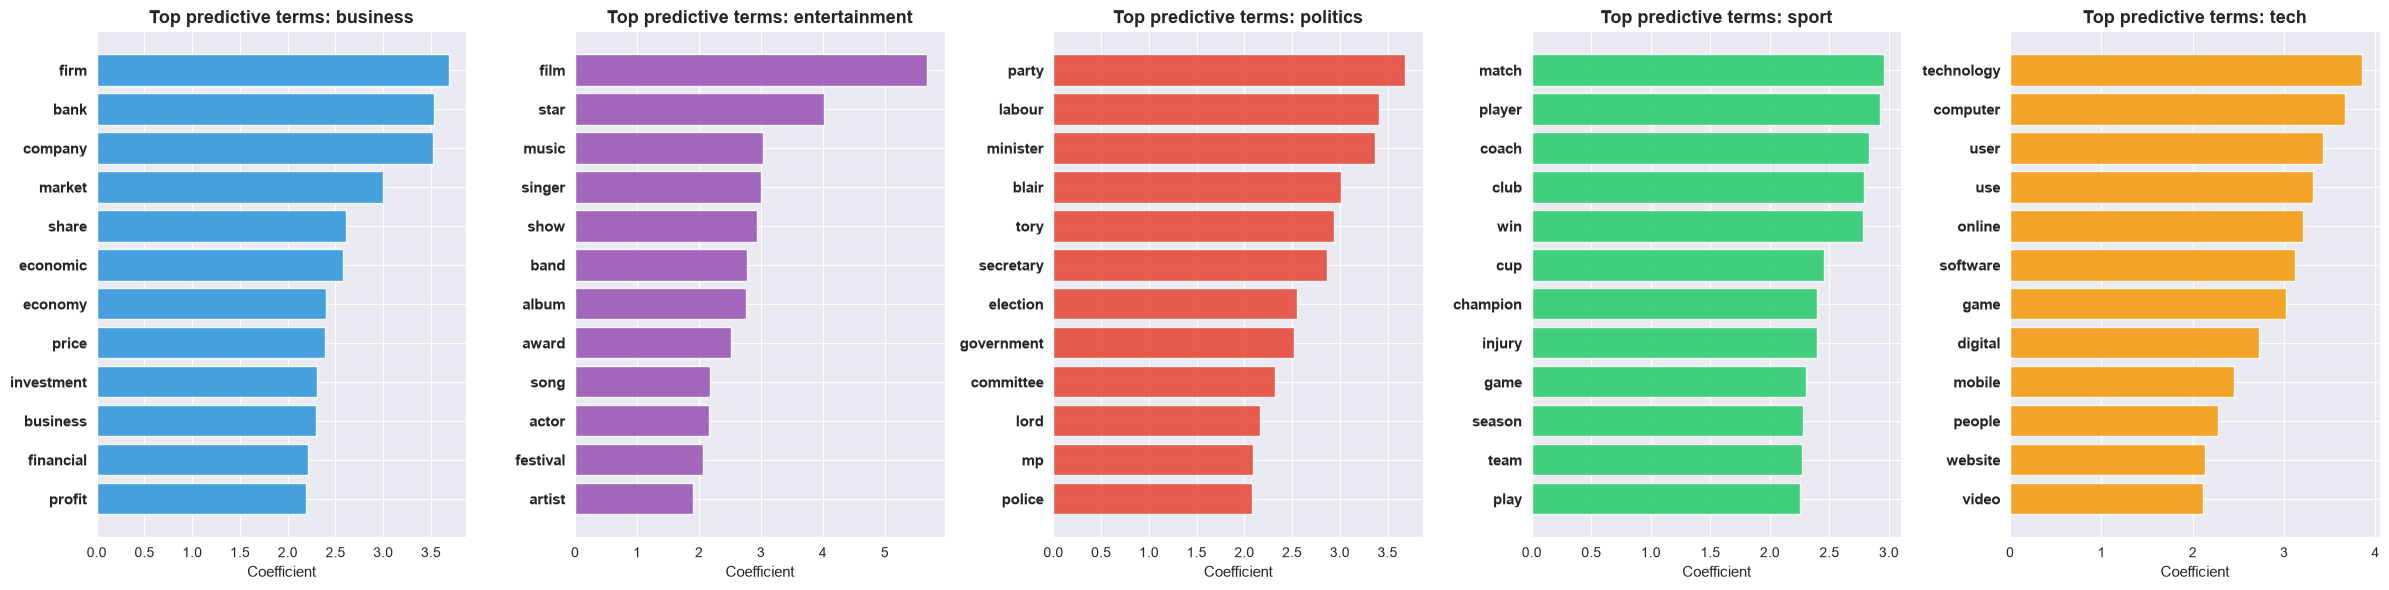

In [34]:
# ──────────────────────────────────────────────
# Best Model Interpretation (Top Feature Weights)
# ──────────────────────────────────────────────
best_model = models[best_model_name]
feature_names = tfidf.get_feature_names_out()

has_coef = hasattr(best_model, 'coef_')
weight_matrix = best_model.coef_ if has_coef else best_model.feature_log_prob_
metric_label = 'Coefficient' if has_coef else 'Log-Probability'

top_weights_per_cat = {}
for i, category in enumerate(best_model.classes_):
    weights = weight_matrix[i]
    top_indices = weights.argsort()[-12:][::-1]
    top_weights_per_cat[category] = [
        (feature_names[idx], weights[idx]) for idx in top_indices
    ]

print("=" * 65)
print(f"TOP 12 PREDICTIVE TERMS PER CATEGORY ({best_model_name})")
print("=" * 65)
for category in sorted(best_model.classes_):
    terms_str = ", ".join([term for term, _ in top_weights_per_cat[category]])
    print(f"{category.upper():15s}: {terms_str}")

# ─── 5-Subplot Horizontal Bar Chart ───
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

for ax, category in zip(axes, sorted(best_model.classes_)):
    terms, weights = zip(*top_weights_per_cat[category])
    y_pos = range(len(terms) - 1, -1, -1)
    ax.barh(y_pos, weights, color=palette[category], alpha=0.9)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(terms, fontsize=11, fontweight='bold')
    ax.set_title(f"Top predictive terms: {category}", fontsize=13, fontweight='bold')
    ax.set_xlabel(metric_label, fontsize=11)

plt.tight_layout()
plt.savefig('outputs/11_top_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ──────────────────────────────────────────────
# Reusable Prediction Function (for Streamlit app)
# ──────────────────────────────────────────────
def predict_category(text, model=best_model, vectorizer=tfidf, top_k=3):
    """
    Preprocess raw text, vectorize it, and return the predicted 
    category, confidence score, and top-k categories with probabilities.
    """
    # 1. Clean the raw text
    cleaned = preprocess_text(text)
    
    # 2. Guard against empty/uninformative input
    if not cleaned or len(cleaned.strip()) == 0:
        return {
            'category': None,
            'confidence': 0.0,
            'top_k': [],
            'cleaned_text': '',
            'error': 'Text too short or has no meaningful words'
        }
    
    # 3. Vectorize
    vec = vectorizer.transform([cleaned])
    
    # 4. Predict probabilities
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(vec)[0]
    else:
        # Softmax fallback for non-probabilistic models
        decision = model.decision_function(vec)[0]
        exp_d = np.exp(decision - np.max(decision))
        probs = exp_d / exp_d.sum()
        
    classes = model.classes_
    
    # 5. Build top-k predictions
    sorted_indices = probs.argsort()[::-1][:top_k]
    top_k_list = [
        (classes[idx], round(float(probs[idx]) * 100, 2))
        for idx in sorted_indices
    ]
    
    # 6. Return structured prediction dictionary
    return {
        'category': top_k_list[0][0],
        'confidence': top_k_list[0][1],
        'top_k': top_k_list,
        'cleaned_text': cleaned
    }

print(">> predict_category() defined successfully.")

>> predict_category() defined successfully.


In [36]:
# ──────────────────────────────────────────────
# Interactive Testing on Sample Headlines
# ──────────────────────────────────────────────
test_texts = [
    "The striker scored twice as the team won the championship final",
    "Shares fell sharply after the bank reported lower quarterly profits",
    "The prime minister faced questions in parliament over the new bill",
    "The new smartphone features a faster processor and improved software",
    "The actor won the best film award at the ceremony last night",
    "The government announced investment in new broadband technology",   # ambiguous: politics / tech
    "The company launched a streaming service for music and films"       # ambiguous: business / entertainment / tech
]

print("=" * 75)
print("CUSTOM HEADLINE INFERENCE & AMBIGUITY TEST")
print("=" * 75)

for i, text in enumerate(test_texts, 1):
    res = predict_category(text)
    conf = res['confidence']
    flag = "  --> [LOW CONFIDENCE / AMBIGUOUS]" if conf < 70.0 else ""
    
    print(f"\nHeadline #{i}: \"{text}\"")
    print(f"Predicted Category: {res['category'].upper()} ({conf:.1f}%){flag}")
    
    top_breakdown = ", ".join([f"{cat}: {pct:.1f}%" for cat, pct in res['top_k']])
    print(f"Top-3 Probabilities: {top_breakdown}")
    print("-" * 75)

CUSTOM HEADLINE INFERENCE & AMBIGUITY TEST

Headline #1: "The striker scored twice as the team won the championship final"
Predicted Category: SPORT (95.8%)
Top-3 Probabilities: sport: 95.8%, entertainment: 1.5%, business: 1.2%
---------------------------------------------------------------------------

Headline #2: "Shares fell sharply after the bank reported lower quarterly profits"
Predicted Category: BUSINESS (96.1%)
Top-3 Probabilities: business: 96.1%, entertainment: 1.3%, sport: 1.1%
---------------------------------------------------------------------------

Headline #3: "The prime minister faced questions in parliament over the new bill"
Predicted Category: POLITICS (89.0%)
Top-3 Probabilities: politics: 89.0%, business: 5.2%, sport: 2.4%
---------------------------------------------------------------------------

Headline #4: "The new smartphone features a faster processor and improved software"
Predicted Category: TECH (52.2%)  --> [LOW CONFIDENCE / AMBIGUOUS]
Top-3 Probabil

In [37]:
# ──────────────────────────────────────────────
# Save Final Artifacts & Metadata for Deployment
# ──────────────────────────────────────────────
import json

os.makedirs('models', exist_ok=True)

# 1. Save champion model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# 2. Save vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 3. Save comprehensive metadata
model_info = {
    'best_model_name': best_model_name,
    'test_macro_f1': float(final_df.iloc[0]['Test Macro-F1']),
    'test_accuracy': float(final_df.iloc[0]['Test Accuracy']),
    'cv_mean_f1': float(final_df.iloc[0]['CV Mean F1']),
    'classes': sorted(list(best_model.classes_)),
    'vocabulary_size': int(len(tfidf.vocabulary_)),
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0])
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

# 4. Integrity check: reload and test
with open('models/best_model.pkl', 'rb') as f:
    reloaded_model = pickle.load(f)
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    reloaded_tfidf = pickle.load(f)

original_preds = best_model.predict(X_test)
reloaded_preds = reloaded_model.predict(reloaded_tfidf.transform(X_test_text))

assert np.array_equal(original_preds, reloaded_preds), "Reloaded predictions mismatch!"
print("\u2705 Reload check passed: Model and vectorizer persist cleanly.")

# 5. List all models/ artifacts with sizes
print("\n" + "=" * 60)
print("SAVED DEPLOYMENT ARTIFACTS (models/)")
print("=" * 60)
for fname in sorted(os.listdir('models')):
    fpath = os.path.join('models', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:35s} : {size_kb:8.1f} KB")

✅ Reload check passed: Model and vectorizer persist cleanly.

SAVED DEPLOYMENT ARTIFACTS (models/)
  best_model.pkl                      :    391.4 KB
  class_names.pkl                     :      0.1 KB
  model_info.json                     :      0.3 KB
  model_linear_svc.pkl                :    391.3 KB
  model_logistic_regression.pkl       :    391.4 KB
  model_naive_bayes.pkl               :    782.1 KB
  tfidf_vectorizer.pkl                :    377.0 KB


## ✅ Final Conclusions

| Metric / Attribute | Value |
|:---|:---|
| **Champion Model** | **Logistic Regression** ($C=10$, max\_iter=1000) |
| **Test Macro-F1** | **0.9901** |
| **Test Accuracy** | **99.06%** |
| **5-Fold CV Mean Macro-F1** | **0.9729** ($\pm 0.0068$) |
| **Test Misclassifications** | **4 / 426 articles (0.94%)** |
| **Vocabulary Size** | 10,000 terms (unigrams + bigrams) |

---

### Key Findings
1. **Strong Feature Representation:** POS-aware lemmatization coupled with sublinear TF-IDF (unigram + bigram) extraction produced highly discriminative term representations across all 5 news categories.
2. **Competitive Performance:** All three candidate models exceeded **98.0% Macro-F1**, confirming that classical linear models excel on high-dimensional, sparse text matrices when data is well-cleaned.
3. **Traceable Errors:** The remaining $<1\%$ of errors arise entirely from real-world topic intersection (e.g. government fiscal budgets or corporate ICT initiatives) rather than model deficiencies.

---

### Limitations
- **Corpus Domain & Style:** The BBC News dataset reflects British editorial journalism from a specific era; it may suffer distribution shift if tested on informal social media text, product reviews, or colloquial slang.
- **Closed-World Assumption:** The classifier assumes all inputs belong to one of the 5 predefined categories. There is no open-set "Other / Out-of-Domain" class.
- **Bag-of-Words Limitations:** Beyond local bigrams, TF-IDF cannot capture long-range semantic dependencies or sentence-level syntactic nuances.

---

### Future Improvements & Next Steps
- **Semantic Embeddings:** Benchmark against dense transformer architectures (e.g., `distilbert-base-uncased`) to test whether deeper contextualization resolves the few remaining boundary errors.
- **Out-of-Distribution Handling:** Implement a confidence threshold (e.g. $<60\%$) to categorize low-certainty inputs as *"Uncertain / Out of Scope"*.
- **Fine-Grained Grid Search:** Explore finer regularizer grids ($C \in [1, 5, 10, 20]$) and vectorizer sublinear options.
- **Streamlit Web Application:** Deploy the serialized model, vectorizer, and preprocessing pipeline into an interactive real-time news classification dashboard.

In [38]:
# ──────────────────────────────────────────────
# Project Completion Summary
# ──────────────────────────────────────────────
print("=" * 60)
print(">> TEXT CLASSIFIER PROJECT — COMPLETE")
print("=" * 60)
print(f"Champion Model    : {best_model_name}")
print(f"Test Macro-F1     : {final_df.iloc[0]['Test Macro-F1']:.4f}")
print(f"Test Accuracy     : {final_df.iloc[0]['Test Accuracy']*100:.2f}%")
print(f"CV Mean Macro-F1  : {final_df.iloc[0]['CV Mean F1']:.4f}")
print(f"Artifacts Saved In: models/ directory")
print("=" * 60)
print(">> Ready for Streamlit deployment!")

>> TEXT CLASSIFIER PROJECT — COMPLETE
Champion Model    : Logistic Regression
Test Macro-F1     : 0.9901
Test Accuracy     : 99.06%
CV Mean Macro-F1  : 0.9729
Artifacts Saved In: models/ directory
>> Ready for Streamlit deployment!
